In [40]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression


In [ ]:
df = pd.read_csv('../../datasets/car_data.csv')

df.sample(5)

,name,year,selling_price,present_price,km_driven,fuel_type,seller_type,transmission,owner
55,corolla altis,2009,3.6,15.04,70000,Petrol,Dealer,Automatic,0
192,Hero Hunk,2007,0.2,0.75,49000,Petrol,Individual,Manual,1
4,swift,2014,4.6,6.87,42450,Diesel,Dealer,Manual,0
12,ciaz,2015,7.5,9.94,15000,Petrol,Dealer,Automatic,0
258,city,2015,8.4,13.60,25000,Petrol,Dealer,Manual,0


In [42]:
df.shape

(301, 9)

In [43]:
df = df.replace('?', np.nan)

In [44]:
df = df.dropna()

In [45]:
df.shape

(301, 9)

#### Drop columns which don't make sense as features

In [46]:
df.drop(['name'], axis=1, inplace=True)

In [47]:
df.sample(5)

,year,selling_price,present_price,km_driven,fuel_type,seller_type,transmission,owner
141,2016,0.60,0.80,20000,Petrol,Individual,Manual,0
251,2013,5.00,9.90,56701,Petrol,Dealer,Manual,0
193,2013,0.20,0.65,24000,Petrol,Individual,Manual,1
198,2011,0.15,0.57,35000,Petrol,Individual,Manual,1
19,2010,2.65,7.98,41442,Petrol,Dealer,Manual,0


In [48]:
df.dtypes

year               int64
selling_price    float64
present_price    float64
km_driven          int64
fuel_type         object
seller_type       object
transmission      object
owner              int64
dtype: object

In [49]:
df['age'] = datetime.datetime.now().year - pd.to_numeric(df['year'])
le = LabelEncoder()
df['fuel_type'] = le.fit_transform(df['fuel_type'])



In [50]:
df.drop(['year'], axis='columns', inplace=True)

In [51]:
df.describe()

,selling_price,present_price,km_driven,fuel_type,owner,age
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,1.787375,0.043189,11.372093
std,5.082812,8.644115,38886.883882,0.425801,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,0.000000,7.000000
25%,0.900000,1.200000,15000.000000,2.000000,0.000000,9.000000
50%,3.600000,6.400000,32000.000000,2.000000,0.000000,11.000000
75%,6.000000,9.900000,48767.000000,2.000000,0.000000,13.000000
max,35.000000,92.600000,500000.000000,2.000000,3.000000,22.000000


### Visualizing relationships

Text(0, 0.5, 'Selling Price')

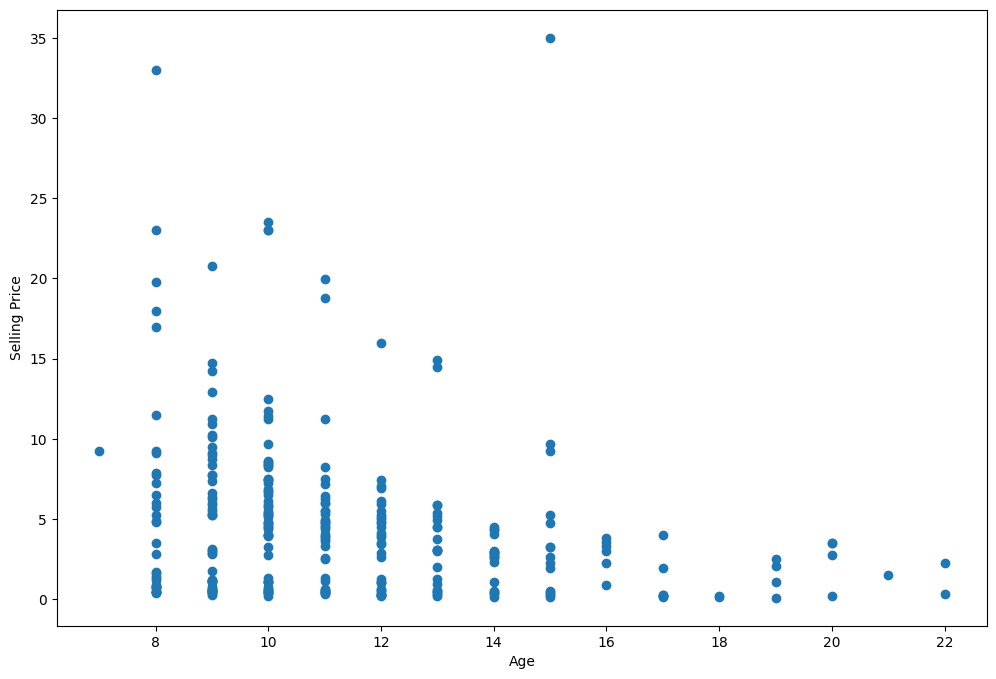

In [52]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(df['age'], df['selling_price'])

plt.xlabel('Age')
plt.ylabel('Selling Price')

Text(0, 0.5, 'Selling Price')

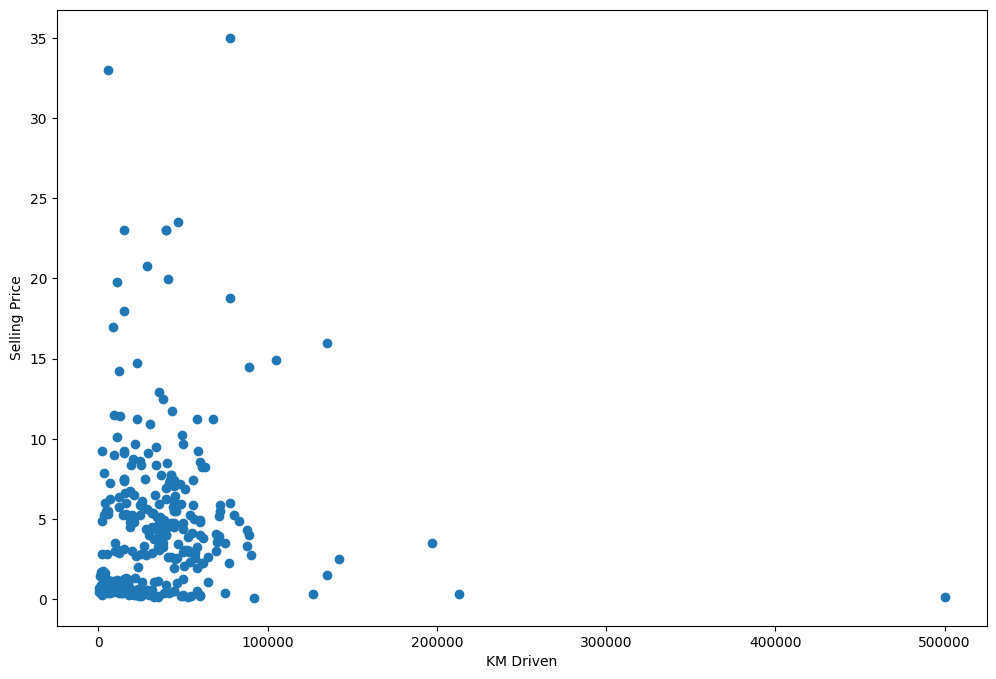

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(df['km_driven'], df['selling_price'])

plt.xlabel('KM Driven')
plt.ylabel('Selling Price')

Text(0, 0.5, 'KM Driven')

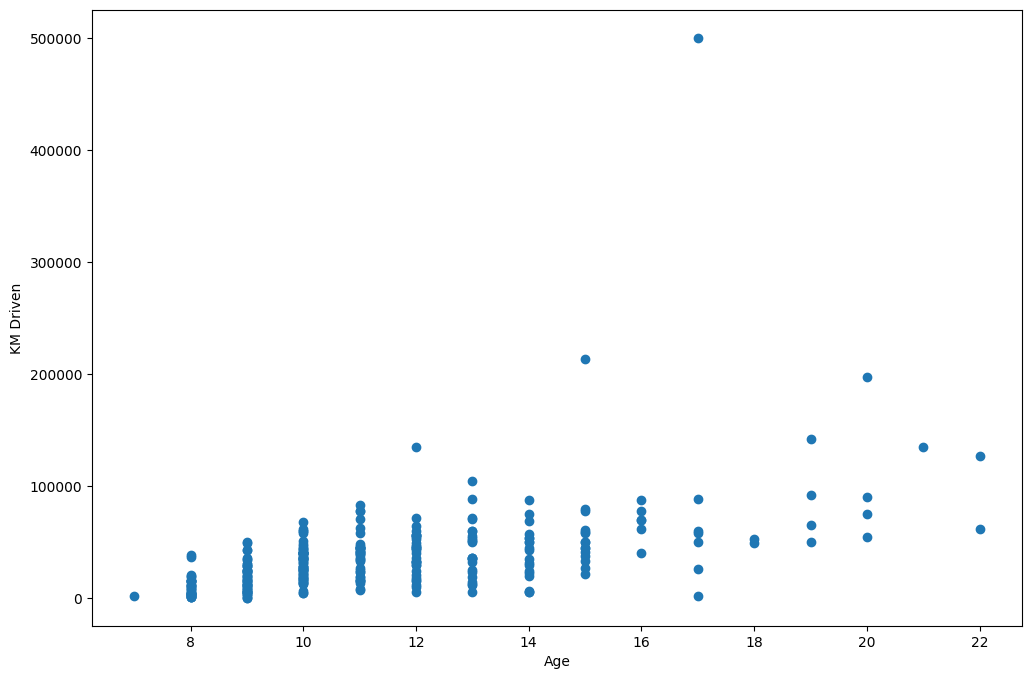

In [54]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(df['age'], df['km_driven'])

plt.xlabel('Age')
plt.ylabel('KM Driven')

Text(0, 0.5, 'KM Driven')

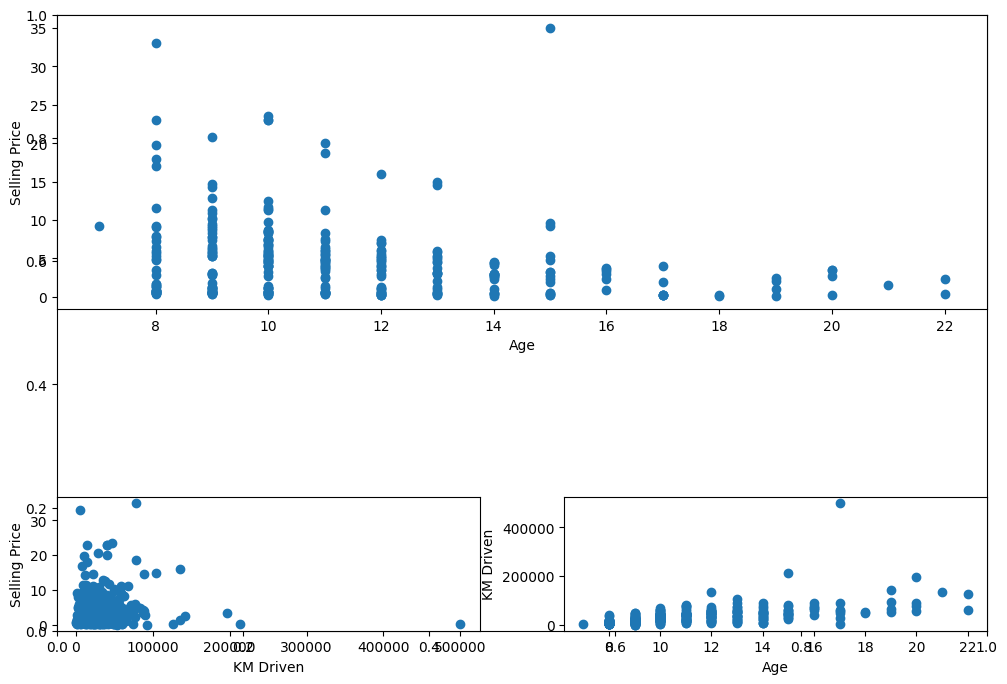

In [55]:
fig, ax = plt.subplots(figsize=(12, 8))

gridsize = (4, 2)
ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=2, rowspan=2) # line
ax2 = plt.subplot2grid(gridsize, (3, 0))
ax3 = plt.subplot2grid(gridsize, (3, 1))
plt.style.use('default')

ax1.scatter(df['age'], df['selling_price'])
ax1.set_xlabel('Age')
ax1.set_ylabel('Selling Price')

ax2.scatter(df['km_driven'], df['selling_price'])
ax2.set_xlabel('KM Driven')
ax2.set_ylabel('Selling Price')

ax3.scatter(df['age'], df['km_driven'])
ax3.set_xlabel('Age')
ax3.set_ylabel('KM Driven')

In [56]:
df_encoded = pd.get_dummies(df, columns=['fuel_type', 'seller_type', 'transmission'], drop_first=True)

# Agora a correlação funciona com todas as colunas numéricas
carprices_corr = df_encoded.corr()

carprices_corr

,selling_price,present_price,km_driven,owner,age,fuel_type_1,fuel_type_2,seller_type_Individual,transmission_Manual
selling_price,1.000000,0.878983,0.029187,-0.088344,-0.236141,0.552339,-0.540571,-0.550724,-0.367128
present_price,0.878983,1.000000,0.203647,0.008057,0.047584,0.473306,-0.465244,-0.512030,-0.348715
km_driven,0.029187,0.203647,1.000000,0.089216,0.524342,0.172515,-0.172874,-0.101419,-0.162510
owner,-0.088344,0.008057,0.089216,1.000000,0.182104,-0.053469,0.055687,0.124269,-0.050316
age,-0.236141,0.047584,0.524342,0.182104,1.000000,-0.064315,0.059959,0.039896,-0.000394
fuel_type_1,0.552339,0.473306,0.172515,-0.053469,-0.064315,1.000000,-0.979648,-0.350467,-0.098643
fuel_type_2,-0.540571,-0.465244,-0.172874,0.055687,0.059959,-0.979648,1.000000,0.358321,0.091013
seller_type_Individual,-0.550724,-0.512030,-0.101419,0.124269,0.039896,-0.350467,0.358321,1.000000,0.063240
transmission_Manual,-0.367128,-0.348715,-0.162510,-0.050316,-0.000394,-0.098643,0.091013,0.063240,1.000000


<Axes: >

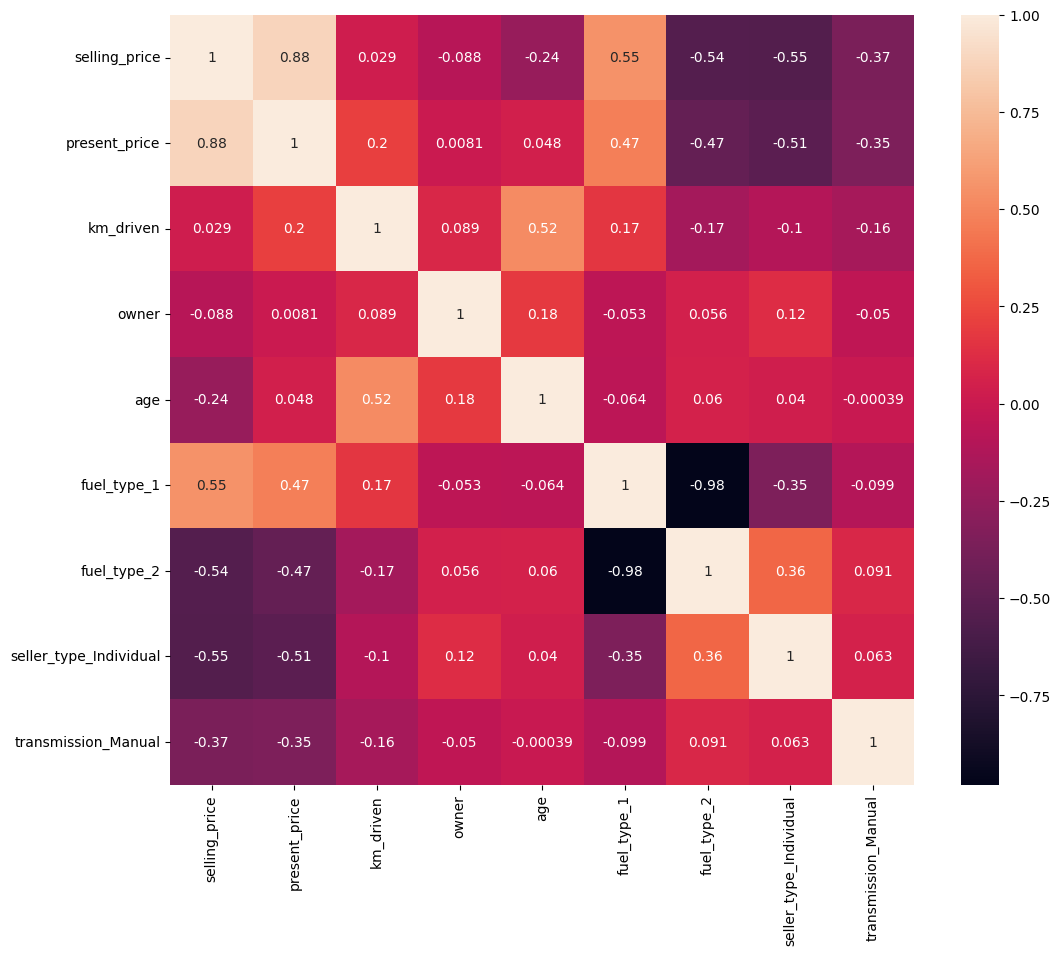

In [57]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(carprices_corr, annot=True)

In [58]:
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,selling_price,present_price,km_driven,fuel_type,seller_type,transmission,owner,age
0,0.35,1.05,30000,2,Individual,Manual,0,14
1,2.35,4.89,54200,2,Dealer,Manual,0,14
2,23.50,35.96,47000,1,Dealer,Automatic,0,10
3,4.50,7.27,40534,2,Dealer,Manual,0,10
4,3.90,5.70,53000,1,Dealer,Manual,0,12


In [150]:
df.shape

(301, 8)

In [151]:
from sklearn.model_selection import train_test_split

X = df[['age']]
Y = df['selling_price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [152]:
x_train.sample(5)

,age
76,8
30,14
294,14
242,14
264,12


In [153]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
linear_model = LinearRegression().fit(x_train_scaled, y_train)


In [156]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.05094311406875118


In [160]:
y_pred = linear_model.predict(x_test_scaled)

In [161]:
from sklearn.metrics import r2_score

print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.07787952242892193


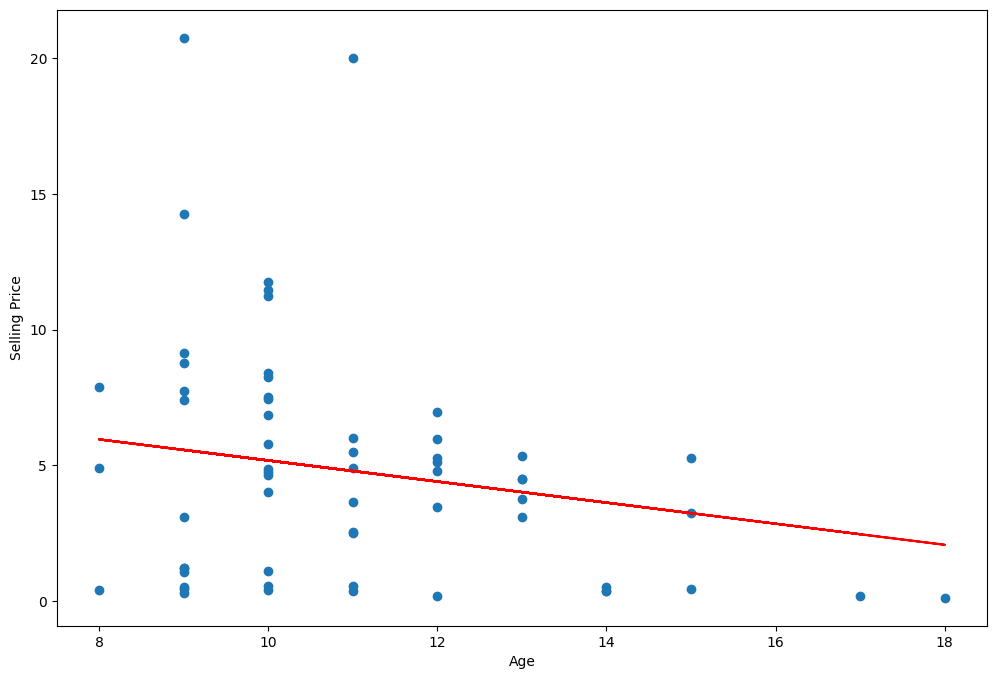

In [162]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='r')

plt.xlabel('Age')
plt.ylabel('Selling Price')
plt.show()

In [163]:
from sklearn.model_selection import train_test_split

X = df[['km_driven']]
Y = df['selling_price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [165]:
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
linear_model = LinearRegression().fit(x_train_scaled, y_train)


In [166]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.013131315225658025


In [168]:
y_pred = linear_model.predict(x_test_scaled)

In [170]:
from sklearn.metrics import r2_score

print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  -0.05594005925816936


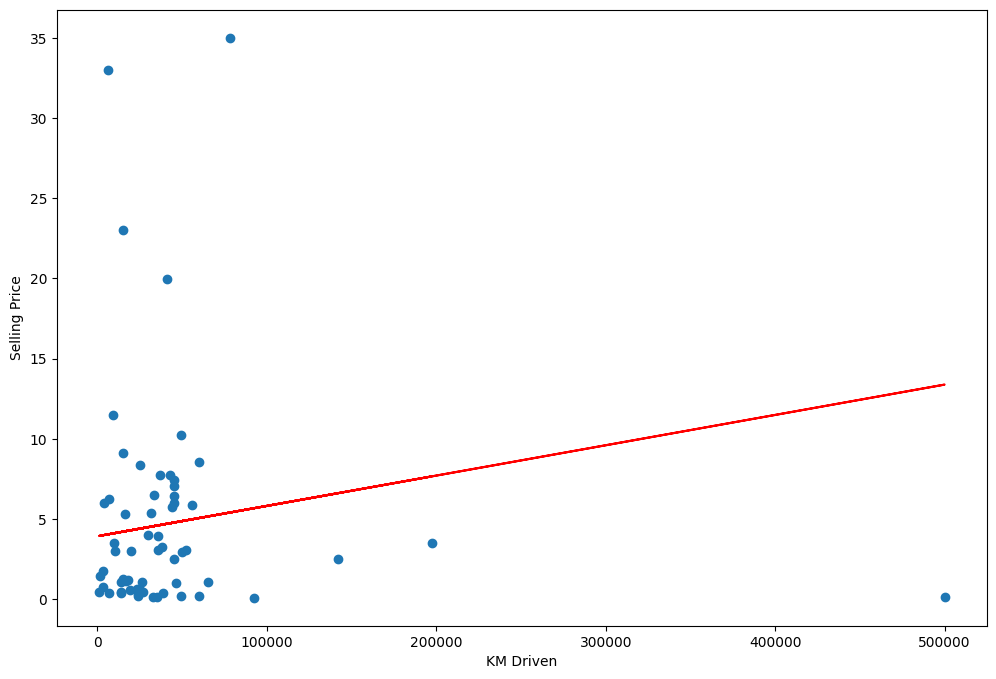

In [171]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='r')

plt.xlabel('KM Driven')
plt.ylabel('Selling Price')
plt.show()

In [172]:
from sklearn.model_selection import train_test_split

X = df[['age']]
Y = df['km_driven']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [173]:
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
linear_model = LinearRegression().fit(x_train_scaled, y_train)

In [174]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.3877909833133397


In [175]:
y_pred = linear_model.predict(x_test_scaled)

In [176]:
from sklearn.metrics import r2_score

print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.15974944518492962


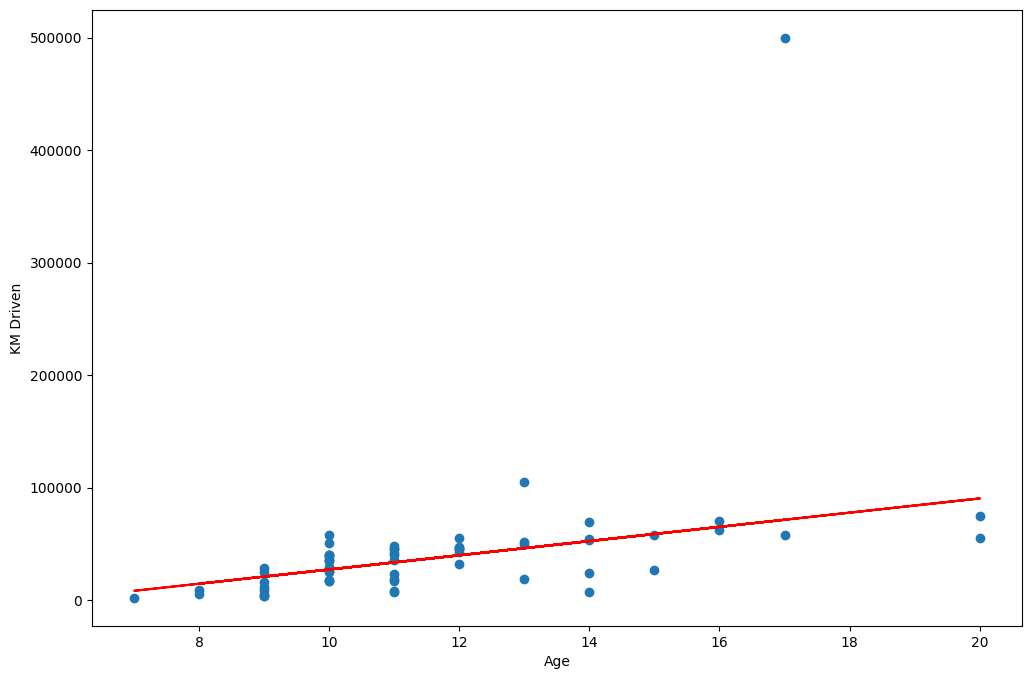

In [177]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='r')

plt.xlabel('Age')
plt.ylabel('KM Driven')
plt.show()

In [178]:
X = df[['age', 'km_driven']]
Y = df['selling_price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [179]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
linear_model = LinearRegression().fit(x_train_scaled, y_train)

In [180]:
print('Training score: ', linear_model.score(x_train_scaled , y_train))

Training score:  0.06987777667644113


In [182]:
predictors = x_train.columns
coef = pd.Series(linear_model.coef_, predictors).sort_values()

print(coef)

age         -1.545778
km_driven    0.897221
dtype: float64


In [184]:
y_pred = linear_model.predict(x_test_scaled)

In [185]:
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.12957069119502262


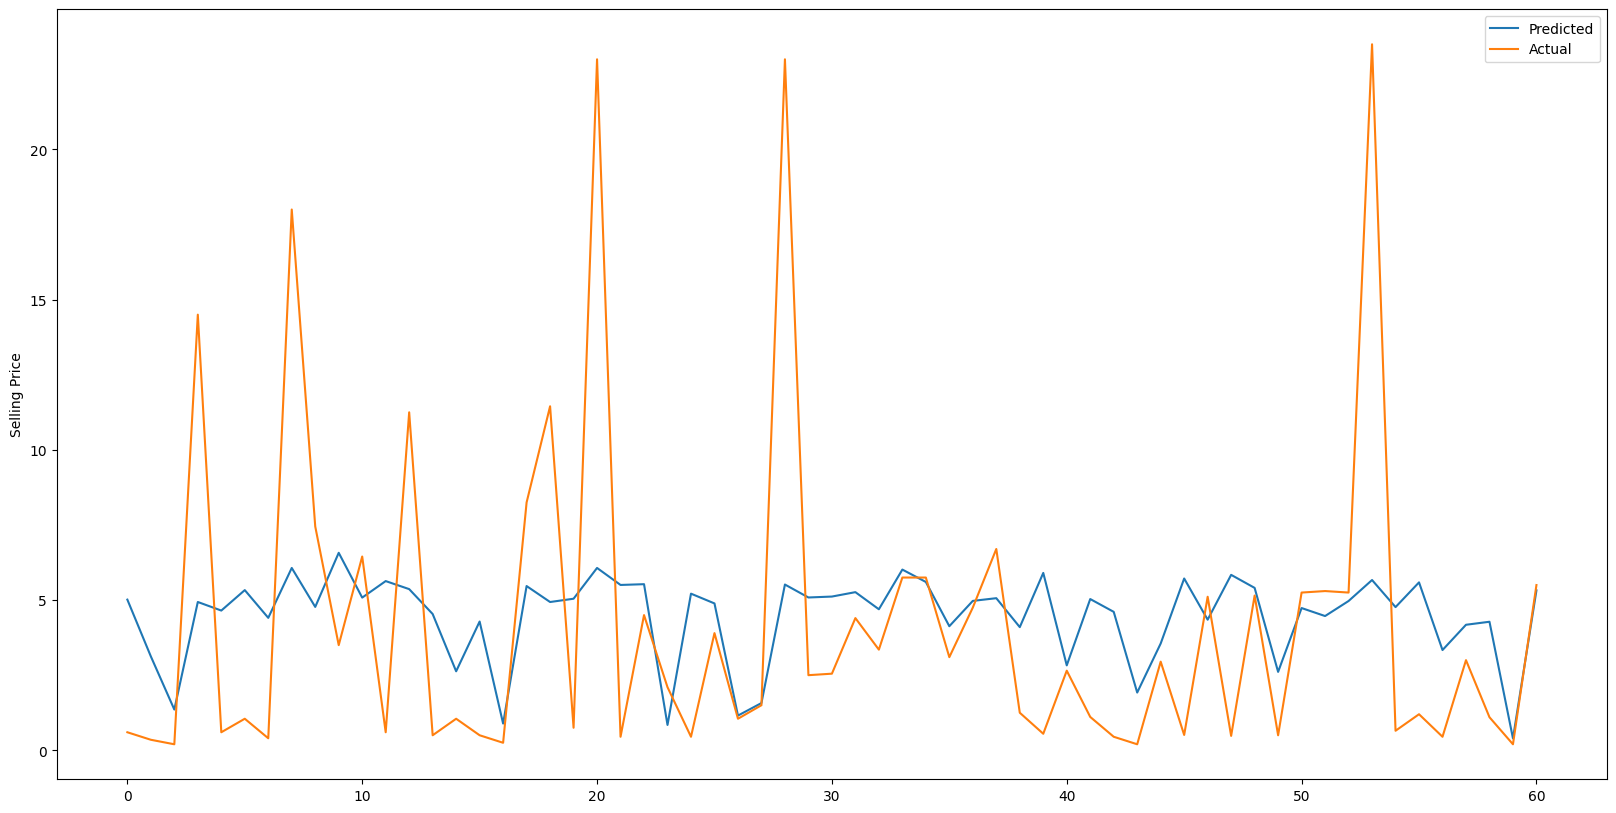

In [187]:
plt.figure(figsize = (20,10))

plt.plot(y_pred, label='Predicted')
plt.plot(y_test.values, label='Actual')

plt.ylabel('Selling Price')

plt.legend()
plt.show()

In [188]:
from sklearn import preprocessing

df[['age']] = preprocessing.scale(df[['age']].astype('float64'))
df[['selling_price']] = preprocessing.scale(df[['selling_price']].astype('float64'))
df[['km_driven']] = preprocessing.scale(df[['km_driven']].astype('float64'))

In [189]:
df.head()

,selling_price,present_price,km_driven,fuel_type,seller_type,transmission,owner,age
0,-0.031786,9.40,-0.021823,2,Dealer,Manual,0,0.563924
1,3.613993,30.61,0.078635,1,Dealer,Automatic,0,-0.475308
2,-0.682115,1.78,-0.797152,2,Individual,Manual,0,-0.821718
3,-0.012079,6.87,0.141743,1,Dealer,Manual,0,-0.128897
4,-0.764884,0.84,-0.822910,2,Individual,Manual,0,-1.168129


In [190]:
df.describe()

,selling_price,present_price,km_driven,fuel_type,owner,age
count,3.010000e+02,301.000000,3.010000e+02,301.000000,301.000000,3.010000e+02
mean,-4.131062e-17,7.628472,7.081821e-17,1.787375,0.043189,-2.478637e-16
std,1.001665e+00,8.644115,1.001665e+00,0.425801,0.247915,1.001665e+00
min,-8.988906e-01,0.320000,-9.388230e-01,0.000000,0.000000,-1.514540e+00
25%,-7.412353e-01,1.200000,-5.653257e-01,2.000000,0.000000,-8.217184e-01
50%,-2.091486e-01,6.400000,-1.274323e-01,2.000000,0.000000,-1.288970e-01
75%,2.638173e-01,9.900000,3.044594e-01,2.000000,0.000000,5.639244e-01
max,5.978822e+00,92.600000,1.192752e+01,2.000000,3.000000,3.681621e+00


In [192]:
df = pd.get_dummies(df, columns=['fuel_type', 'seller_type', 'transmission', 'owner'])

In [193]:
df.head()

,selling_price,present_price,km_driven,age,fuel_type_0,fuel_type_1,fuel_type_2,seller_type_Dealer,seller_type_Individual,transmission_Automatic,transmission_Manual,owner_0,owner_1,owner_3
0,-0.031786,9.40,-0.021823,0.563924,False,False,True,True,False,False,True,True,False,False
1,3.613993,30.61,0.078635,-0.475308,False,True,False,True,False,True,False,True,False,False
2,-0.682115,1.78,-0.797152,-0.821718,False,False,True,False,True,False,True,True,False,False
3,-0.012079,6.87,0.141743,-0.128897,False,True,False,True,False,False,True,True,False,False
4,-0.764884,0.84,-0.822910,-1.168129,False,False,True,False,True,False,True,True,False,False


In [194]:
from sklearn.model_selection import train_test_split

X = df.drop('selling_price', axis=1)
Y = df['selling_price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [195]:
x_train.shape, x_test.shape

((240, 13), (61, 13))

In [196]:
y_train.shape, y_test.shape

((240,), (61,))

In [197]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression(fit_intercept=True).fit(x_train, y_train)

In [198]:
print("Training_score : " , linear_model.score(x_train, y_train))

Training_score :  0.8813490796656589


In [199]:
y_pred = linear_model.predict(x_test)

In [200]:
from sklearn.metrics import r2_score

print("Testing_score : ", r2_score(y_test, y_pred))

Testing_score :  0.8195261709563022


In [201]:
df_pred_actual = pd.DataFrame({'predicted': y_pred, 'actual': y_test})

df_pred_actual.head(10)

,predicted,actual
72,0.249770,0.342645
276,-0.532376,-0.475192
56,-0.449717,-0.829916
238,-0.016898,-0.130321
123,-0.336792,-0.337244
94,0.722104,0.992973
172,-0.701813,-0.770796
181,0.708340,0.736783
116,0.487605,0.500300
80,-0.113479,-0.179588


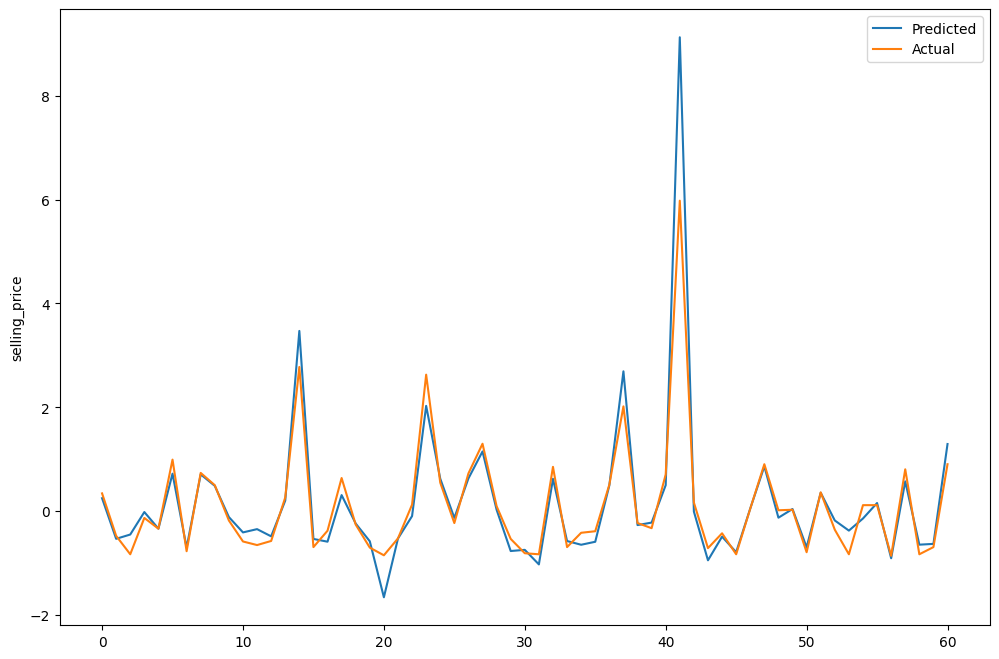

In [202]:
plt.figure(figsize = (12, 8))

plt.plot(y_pred, label='Predicted')
plt.plot(y_test.values, label='Actual')

plt.ylabel('selling_price')

plt.legend()
plt.show()